## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Data preparation and analysis

In [2]:
load_df = pd.read_csv("./dataset/Social_Network_Ads.csv")
df = pd.DataFrame(load_df)

df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [3]:
# 1. Dataset Shape and Basic Info
print("Dataset Shape:", df.shape)
print("\n--- Info ---")
df.info()

Dataset Shape: (400, 5)

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [4]:
# 2. Statistical Summary of Numerical Columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


In [5]:
# 3. Missing Values Check
print("Missing values in each column:\n")
print(df.isnull().sum())

Missing values in each column:

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


Purchased
0    64.25
1    35.75
Name: proportion, dtype: float64


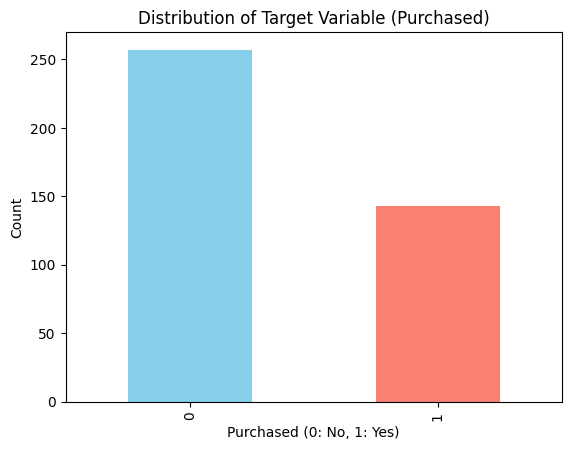

In [8]:
# 4. Target Variable Distribution (Value Counts)
# Adjust 'Purchased' if your target column name differs
if 'Purchased' in df.columns:
    print(df['Purchased'].value_counts(normalize=True) * 100)
    df['Purchased'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
    plt.title('Distribution of Target Variable (Purchased)')
    plt.xlabel('Purchased (0: No, 1: Yes)')
    plt.ylabel('Count')
    plt.show()
else:
    print("Column 'Purchased' not found.")

In [10]:
# 5. Correlation Matrix for Numerical Columns
# This helps identify strong pairwise relationships between features and the target
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()
print("Correlation Matrix:\n")
print(corr_matrix)

# Visualize using pandas styling
corr_matrix.style.background_gradient(cmap='coolwarm', axis=None).format(precision=3)

Correlation Matrix:

                  User ID       Age  EstimatedSalary  Purchased
User ID          1.000000 -0.000721         0.071097   0.007120
Age             -0.000721  1.000000         0.155238   0.622454
EstimatedSalary  0.071097  0.155238         1.000000   0.362083
Purchased        0.007120  0.622454         0.362083   1.000000


,User ID,Age,EstimatedSalary,Purchased
User ID,1.000,-0.001,0.071,0.007
Age,-0.001,1.000,0.155,0.622
EstimatedSalary,0.071,0.155,1.000,0.362
Purchased,0.007,0.622,0.362,1.000


for the sake of simple logistic regression (one dependent variable), we choose Age as the dependent to classify users those who purchased and not when exposed to ads. Why Age? because it has the highest correlation with the purhcased category.